In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from analysis_utils import *

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Adjust font sizes:
# Set global sizes
plt.rcParams.update({
    'font.size': 18,          # Base font size
    'axes.titlesize': 24,     # Title size
    'axes.labelsize': 20,     # X and Y label size
    'xtick.labelsize': 16,    # X tick label size
    'ytick.labelsize': 16,    # Y tick label size
    'legend.fontsize': 16,    # Legend size
    'lines.linewidth': 3,     # Thicker lines for visibility
    'lines.markersize': 10    # Larger markers
})        

First define the two experiments to be compared:

In [3]:
results_1 = "./analysis_results/2022_barn_2secs_myca_quantile_1_16"
results_2 = "./analysis_results/2022_lake_2secs_myca_quantile_1_28"
exp_1_name = "Barn"
exp_2_name = "Lake"

In [4]:
chirp_attributes_1 = pd.read_csv(f"{results_1}/test_set_chirp_attributes.csv")
chirp_attributes_1 = pd.read_csv(f"{results_1}/all_chirp_measures_scaled.csv")
idiom_boundaries_1 = pd.read_csv(f"{results_1}/idiom_boundaries.csv", header=None)
confidence_measures_1 = pd.read_csv(f"{results_1}/chirp_prediction_confidence_measures.csv")

chirp_attributes_2 = pd.read_csv(f"{results_2}/test_set_chirp_attributes.csv")
chirp_attributes_2 = pd.read_csv(f"{results_2}/all_chirp_measures_scaled.csv")
idiom_boundaries_2 = pd.read_csv(f"{results_2}/idiom_boundaries.csv", header=None)
confidence_measures_2 = pd.read_csv(f"{results_2}/chirp_prediction_confidence_measures.csv")

In [5]:
combined_chirp_attributes = pd.concat([chirp_attributes_1, chirp_attributes_2], ignore_index=False).reset_index()
combined_chirp_attributes.rename({"index": "OriginalIndex"}, axis=1, inplace=True)
idiom_boundaries_attributes = pd.concat([idiom_boundaries_1, idiom_boundaries_2], ignore_index=False).reset_index()
idiom_boundaries_attributes.rename({"index": "OriginalIndex"}, axis=1, inplace=True)
confidence_measures_attributes = pd.concat([confidence_measures_1, confidence_measures_2], ignore_index=False).reset_index()
confidence_measures_attributes.rename({"index": "OriginalIndex"}, axis=1, inplace=True)
combined_chirp_attributes

,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,...,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom
0,0,0.136338,-1.705570,0.299929,0.350269,0.883035,-0.425024,0.654794,0.060432,0.306857,...,0.801789,1.080712,1.252566,-0.458611,16693.0,0.0,3,False,False,False
1,1,0.557182,0.253606,-1.451814,-1.894761,0.048584,0.317602,-0.519166,-0.767268,-1.456233,...,-1.334171,-1.367762,-1.127589,0.213598,16693.0,1.0,0,False,False,False
2,2,0.655343,0.193143,-0.659362,-0.957316,0.178254,0.329277,-0.455645,0.041083,-0.668940,...,-0.416620,0.060343,-0.179759,0.281849,16693.0,2.0,0,False,False,False
3,3,0.772126,-0.933910,-0.762999,-1.163437,0.239718,0.903683,-0.359275,0.754203,-0.771179,...,-1.005365,-0.893995,-0.927817,0.632165,16693.0,3.0,0,False,False,False
4,4,0.896717,0.832006,-0.578147,-0.613285,0.223689,-0.695453,-1.385929,1.638830,-0.580797,...,-0.781688,-0.700437,-0.794223,-1.046507,16693.0,4.0,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14984,757,-0.129670,0.793602,-2.296108,-1.993205,0.882566,-2.751209,-1.930351,0.993843,-2.274968,...,-0.892759,-1.026545,-0.752214,-1.256265,1090.0,9.0,3,False,False,False
14985,758,-0.011291,0.207223,0.047872,0.430694,-1.109137,0.819466,0.676231,-0.900135,0.039999,...,-0.170814,-0.379035,-0.232871,1.076593,1090.0,10.0,8,False,False,False
14986,759,0.230353,0.353487,0.019177,0.348155,-0.535655,0.686851,0.460256,-0.072917,0.010857,...,-0.124500,0.393080,-0.134332,0.107975,1090.0,11.0,4,False,False,False
14987,760,0.322932,-0.570161,0.345809,0.262485,0.387178,0.507593,1.281610,-0.246454,0.329250,...,0.049120,0.595467,0.266323,-0.686388,1090.0,12.0,6,False,False,False


In [6]:
for dataframe, df_1 in [(combined_chirp_attributes, chirp_attributes_1), 
                        (idiom_boundaries_attributes, idiom_boundaries_1), 
                        (confidence_measures_attributes, confidence_measures_1)]:
    dataframe["original_df"] = dataframe.apply(lambda x: 1 if x.name < len(df_1) else 2, axis=1)
combined_chirp_attributes

,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,...,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom,original_df
0,0,0.136338,-1.705570,0.299929,0.350269,0.883035,-0.425024,0.654794,0.060432,0.306857,...,1.080712,1.252566,-0.458611,16693.0,0.0,3,False,False,False,1
1,1,0.557182,0.253606,-1.451814,-1.894761,0.048584,0.317602,-0.519166,-0.767268,-1.456233,...,-1.367762,-1.127589,0.213598,16693.0,1.0,0,False,False,False,1
2,2,0.655343,0.193143,-0.659362,-0.957316,0.178254,0.329277,-0.455645,0.041083,-0.668940,...,0.060343,-0.179759,0.281849,16693.0,2.0,0,False,False,False,1
3,3,0.772126,-0.933910,-0.762999,-1.163437,0.239718,0.903683,-0.359275,0.754203,-0.771179,...,-0.893995,-0.927817,0.632165,16693.0,3.0,0,False,False,False,1
4,4,0.896717,0.832006,-0.578147,-0.613285,0.223689,-0.695453,-1.385929,1.638830,-0.580797,...,-0.700437,-0.794223,-1.046507,16693.0,4.0,0,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14984,757,-0.129670,0.793602,-2.296108,-1.993205,0.882566,-2.751209,-1.930351,0.993843,-2.274968,...,-1.026545,-0.752214,-1.256265,1090.0,9.0,3,False,False,False,2
14985,758,-0.011291,0.207223,0.047872,0.430694,-1.109137,0.819466,0.676231,-0.900135,0.039999,...,-0.379035,-0.232871,1.076593,1090.0,10.0,8,False,False,False,2
14986,759,0.230353,0.353487,0.019177,0.348155,-0.535655,0.686851,0.460256,-0.072917,0.010857,...,0.393080,-0.134332,0.107975,1090.0,11.0,4,False,False,False,2
14987,760,0.322932,-0.570161,0.345809,0.262485,0.387178,0.507593,1.281610,-0.246454,0.329250,...,0.595467,0.266323,-0.686388,1090.0,12.0,6,False,False,False,2


Visualize how the two experiments are distributed in a 2-D projection:

In [7]:
import umap
combined_chirp_attributes_embedded = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(combined_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy())

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


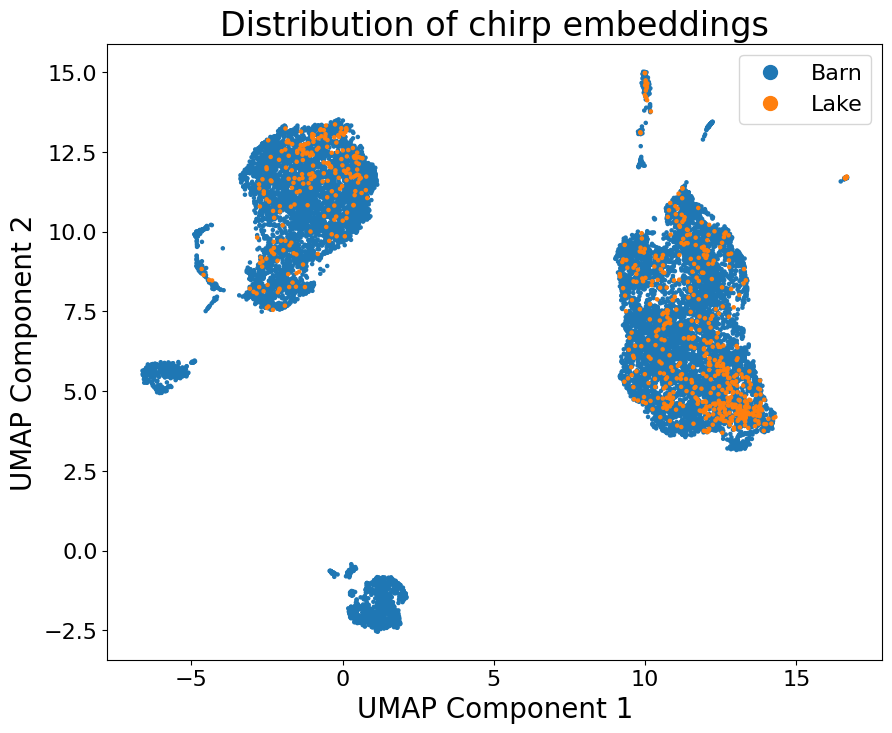

In [8]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(combined_chirp_attributes_embedded[:, 0], 
                      combined_chirp_attributes_embedded[:, 1], 
                      c=combined_chirp_attributes["original_df"], 
                      cmap="tab10",
                      vmin=1,
                      vmax=10,
                      s=5,
                      )
plt.title(f"Distribution of chirp embeddings")# in UMAP space")
handles, labels = scatter.legend_elements()
plt.legend(handles, [exp_1_name, exp_2_name])
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

In [9]:
idiom_boundaries_attributes

,OriginalIndex,0,1,original_df
0,0,2.0,11.0,1
1,1,49.0,54.0,1
2,2,62.0,70.0,1
3,3,95.0,99.0,1
4,4,111.0,115.0,1
...,...,...,...,...
633,2,315.0,319.0,2
634,3,328.0,337.0,2
635,4,434.0,443.0,2
636,5,462.0,468.0,2


Visualize the distribution of only idiom chirps (chirps within a "whole" idiom):

In [10]:
# get the idiom chirp attributes
idiom_chirp_idxs = []
for idx, row in idiom_boundaries_attributes.iterrows():
    for i in range(int(row[0]), int(row[1]) + 1):
        idiom_chirp_idxs.append((idx, i, row["original_df"]))

idiom_chirp_attributes = pd.DataFrame()
for idiom_idx, chirp_idx, original_df in idiom_chirp_idxs:
    attributes = combined_chirp_attributes.loc[(combined_chirp_attributes["original_df"] == original_df) & 
                                                (combined_chirp_attributes["OriginalIndex"] == chirp_idx)]
    if idiom_chirp_attributes.empty:
        idiom_chirp_attributes = attributes
    else:
        idiom_chirp_attributes = pd.concat([idiom_chirp_attributes, attributes])
idiom_chirp_attributes.reset_index(inplace=True)
idiom_chirp_attributes

,index,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom,original_df
0,2,2,0.655343,0.193143,-0.659362,-0.957316,0.178254,0.329277,-0.455645,0.041083,...,0.060343,-0.179759,0.281849,16693.0,2.0,0,False,False,False,1
1,3,3,0.772126,-0.933910,-0.762999,-1.163437,0.239718,0.903683,-0.359275,0.754203,...,-0.893995,-0.927817,0.632165,16693.0,3.0,0,False,False,False,1
2,4,4,0.896717,0.832006,-0.578147,-0.613285,0.223689,-0.695453,-1.385929,1.638830,...,-0.700437,-0.794223,-1.046507,16693.0,4.0,0,False,False,False,1
3,5,5,-5.199337,-5.199337,-1.689194,-1.798612,-0.397388,-0.690617,-1.810447,2.008046,...,-1.935308,-1.990845,-0.251563,16694.0,0.0,8,False,False,False,1
4,6,6,-1.401177,1.856399,0.458497,-0.209801,1.275717,0.090926,1.754126,-0.583544,...,0.776812,1.014512,0.156473,16694.0,1.0,2,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4062,14771,544,-1.508351,-5.199337,-0.085526,-0.316722,0.855925,-0.819994,0.509387,-0.092286,...,-0.100597,-0.140417,-0.432270,1077.0,0.0,0,False,False,False,2
4063,14772,545,-1.048748,-0.641002,0.356087,-0.098315,0.676468,0.025702,1.258461,-0.520603,...,-0.659738,-0.281266,0.542054,1077.0,1.0,5,False,False,False,2
4064,14773,546,-0.666097,-0.205941,0.318922,-0.296259,0.972327,0.255579,1.648409,-0.767032,...,-0.037962,0.284540,0.640516,1077.0,2.0,5,False,False,False,2
4065,14774,547,-0.508627,0.920412,-0.907659,-1.087665,1.008148,-1.922393,-0.122136,-1.395092,...,-0.422324,-1.150765,-1.595424,1077.0,3.0,8,False,False,False,2


In [11]:
NO_AMP = 2 # set to 0 to keep all amp features, 1 to remove [Amp1stQrtl, Amp2ndQrtl, Amp3rdQrtl, Amp4thQrtl], 2 to remove all amp features

idiom_chirp_data = idiom_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy()

# remove columns that contain "Amp" in their name if NO_AMP is set
if NO_AMP == 1:
    amp_indices = [i - 3 for i, col in enumerate(idiom_chirp_attributes.columns) if col in ["Amp1stQrtl", "Amp2ndQrtl", "Amp3rdQrtl", "Amp4thQrtl"]]
    idiom_chirp_data = np.delete(idiom_chirp_data, amp_indices, axis=1)
elif NO_AMP == 2:
    amp_indices = [i - 3 for i, col in enumerate(idiom_chirp_attributes.columns) if "Amp" in col]
    idiom_chirp_data = np.delete(idiom_chirp_data, amp_indices, axis=1)

In [12]:
idiom_chirp_data

array([[ 0.19314317, -0.65936178, -0.95731634, ..., -0.41661969,
         0.06034276, -0.17975859],
       [-0.93390995, -0.76299906, -1.16343737, ..., -1.00536478,
        -0.89399517, -0.9278174 ],
       [ 0.8320063 , -0.57814664, -0.6132854 , ..., -0.78168756,
        -0.70043653, -0.79422265],
       ...,
       [-0.2059412 ,  0.31892222, -0.29625943, ...,  0.1138511 ,
        -0.03796245,  0.28453997],
       [ 0.9204123 , -0.90765917, -1.08766532, ..., -1.39000142,
        -0.42232358, -1.15076542],
       [ 0.6784325 , -0.17884393, -0.32015324, ..., -0.3717855 ,
        -0.44072992, -0.53256965]])

In [13]:
idiom_chirp_attributes_embedded = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(idiom_chirp_data)

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


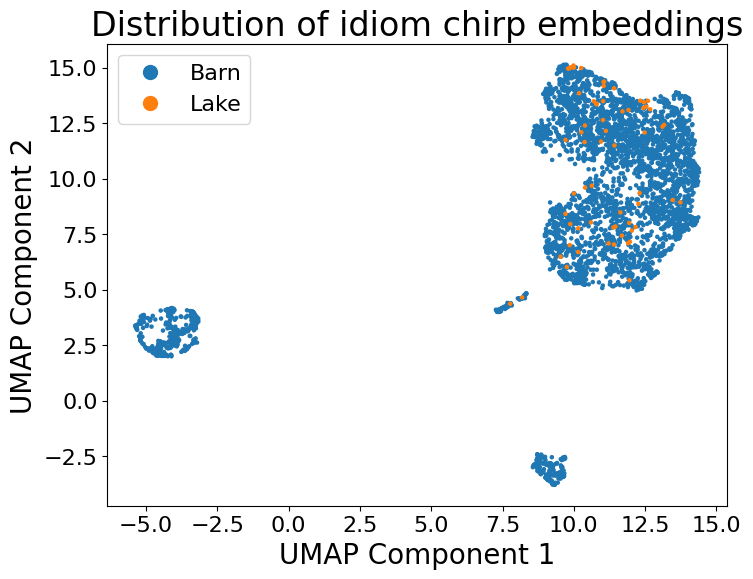

In [14]:
# FIGURE: 10.2

plt.figure(figsize=(8, 6))
scatter = plt.scatter(idiom_chirp_attributes_embedded[:, 0], 
                      idiom_chirp_attributes_embedded[:, 1], 
                      c=idiom_chirp_attributes["original_df"], 
                      cmap="tab10",
                      vmin=1,
                      vmax=10,
                      s=5,
                      )
plt.title(f"Distribution of idiom chirp embeddings")# in UMAP space")
handles, labels = scatter.legend_elements()
plt.legend(handles, [exp_1_name, exp_2_name])
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

Run clustering on the set of idiom chirps combined from both idioms:

In [15]:
MIN_K = 1
MAX_K = 50

n_clusters = find_ideal_cluster_k(idiom_chirp_attributes_embedded, MIN_K, MAX_K, plot=False)
n_clusters

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)
100%|██████████| 49/49 [00:11<00:00,  4.11it/s]


{'gap_statistic': 45, 'diff_statistic': 1, 'elbow_method': 7}

In [16]:
clustering = "Agglomerative"
use_umap = True
NUM_CLUSTERS = n_clusters["elbow_method"]

cluster_data_input = idiom_chirp_attributes_embedded if use_umap else idiom_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy()
chirp_labels = cluster_chirps(cluster_data_input, clustering, use_umap, NUM_CLUSTERS)

chirp_labels

array([2, 2, 2, ..., 1, 2, 0])

In [17]:
idiom_chirp_attributes

,index,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom,original_df
0,2,2,0.655343,0.193143,-0.659362,-0.957316,0.178254,0.329277,-0.455645,0.041083,...,0.060343,-0.179759,0.281849,16693.0,2.0,0,False,False,False,1
1,3,3,0.772126,-0.933910,-0.762999,-1.163437,0.239718,0.903683,-0.359275,0.754203,...,-0.893995,-0.927817,0.632165,16693.0,3.0,0,False,False,False,1
2,4,4,0.896717,0.832006,-0.578147,-0.613285,0.223689,-0.695453,-1.385929,1.638830,...,-0.700437,-0.794223,-1.046507,16693.0,4.0,0,False,False,False,1
3,5,5,-5.199337,-5.199337,-1.689194,-1.798612,-0.397388,-0.690617,-1.810447,2.008046,...,-1.935308,-1.990845,-0.251563,16694.0,0.0,8,False,False,False,1
4,6,6,-1.401177,1.856399,0.458497,-0.209801,1.275717,0.090926,1.754126,-0.583544,...,0.776812,1.014512,0.156473,16694.0,1.0,2,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4062,14771,544,-1.508351,-5.199337,-0.085526,-0.316722,0.855925,-0.819994,0.509387,-0.092286,...,-0.100597,-0.140417,-0.432270,1077.0,0.0,0,False,False,False,2
4063,14772,545,-1.048748,-0.641002,0.356087,-0.098315,0.676468,0.025702,1.258461,-0.520603,...,-0.659738,-0.281266,0.542054,1077.0,1.0,5,False,False,False,2
4064,14773,546,-0.666097,-0.205941,0.318922,-0.296259,0.972327,0.255579,1.648409,-0.767032,...,-0.037962,0.284540,0.640516,1077.0,2.0,5,False,False,False,2
4065,14774,547,-0.508627,0.920412,-0.907659,-1.087665,1.008148,-1.922393,-0.122136,-1.395092,...,-0.422324,-1.150765,-1.595424,1077.0,3.0,8,False,False,False,2


In [18]:
import matplotlib 
from matplotlib.colors import ListedColormap

cmap1_colors = matplotlib.colormaps["tab10"](np.linspace(0, 1, 256))
cmap2_colors = cmap1_colors * 0.5
cmap2_colors[:, 3] = 1
cmap2_colors
cmap2 = ListedColormap(cmap2_colors, name="Set1dark")

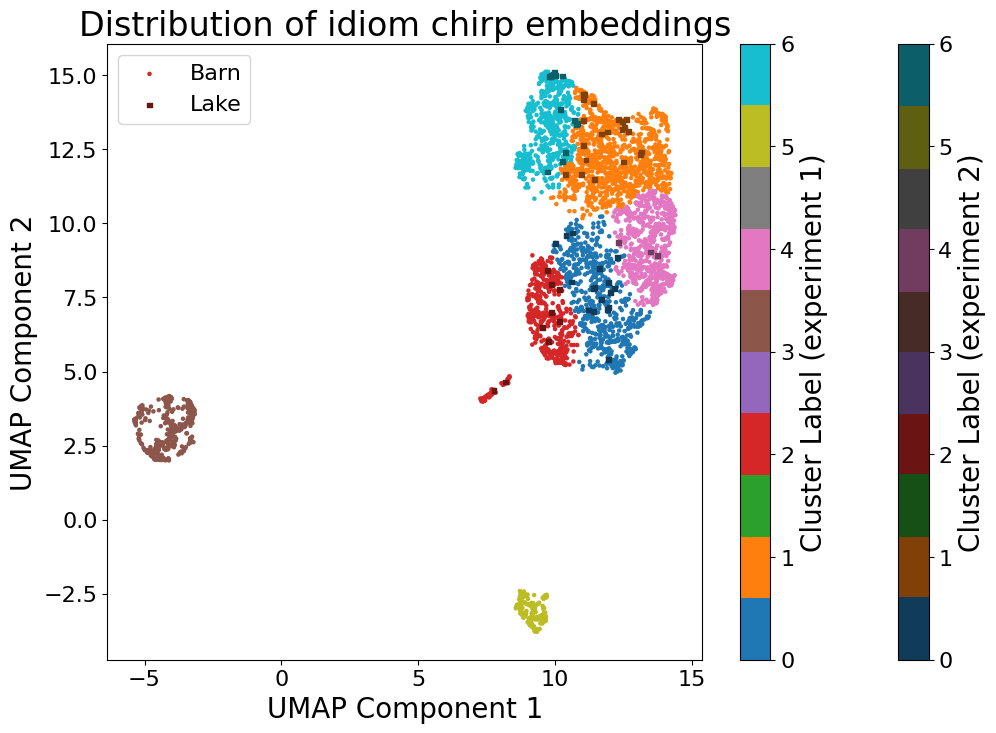

In [19]:
# FIGURE: 11.1

# plot the idiom chirps with their clusters, with the two experiments designated with different shapes
second_exp_first_row = idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 2].iloc[0].name

plt.figure(figsize=(12, 8))
scatter1 = plt.scatter(idiom_chirp_attributes_embedded[:second_exp_first_row, 0], 
                      idiom_chirp_attributes_embedded[:second_exp_first_row, 1], 
                      c=chirp_labels[:second_exp_first_row], 
                      cmap="tab10", 
                      s=5, 
                      vmin=min(chirp_labels), 
                      vmax=NUM_CLUSTERS - 1
                      )
scatter2 = plt.scatter(idiom_chirp_attributes_embedded[second_exp_first_row:, 0], 
                      idiom_chirp_attributes_embedded[second_exp_first_row:, 1], 
                      c=chirp_labels[second_exp_first_row:], 
                      cmap=cmap2, 
                      s=12, 
                      marker="s",
                      vmin=min(chirp_labels), 
                      vmax=NUM_CLUSTERS - 1
                      )
plt.title(f"Distribution of idiom chirp embeddings")# in UMAP space")
# handles, labels = scatter1.legend_elements()
# plt.legend(handles, ["barn", "lake"])
plt.colorbar(scatter2, label="Cluster Label (experiment 2)")
plt.colorbar(scatter1, label="Cluster Label (experiment 1)")
plt.legend([exp_1_name, exp_2_name])

plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

In [20]:
idiom_chirp_attributes

,index,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom,original_df
0,2,2,0.655343,0.193143,-0.659362,-0.957316,0.178254,0.329277,-0.455645,0.041083,...,0.060343,-0.179759,0.281849,16693.0,2.0,0,False,False,False,1
1,3,3,0.772126,-0.933910,-0.762999,-1.163437,0.239718,0.903683,-0.359275,0.754203,...,-0.893995,-0.927817,0.632165,16693.0,3.0,0,False,False,False,1
2,4,4,0.896717,0.832006,-0.578147,-0.613285,0.223689,-0.695453,-1.385929,1.638830,...,-0.700437,-0.794223,-1.046507,16693.0,4.0,0,False,False,False,1
3,5,5,-5.199337,-5.199337,-1.689194,-1.798612,-0.397388,-0.690617,-1.810447,2.008046,...,-1.935308,-1.990845,-0.251563,16694.0,0.0,8,False,False,False,1
4,6,6,-1.401177,1.856399,0.458497,-0.209801,1.275717,0.090926,1.754126,-0.583544,...,0.776812,1.014512,0.156473,16694.0,1.0,2,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4062,14771,544,-1.508351,-5.199337,-0.085526,-0.316722,0.855925,-0.819994,0.509387,-0.092286,...,-0.100597,-0.140417,-0.432270,1077.0,0.0,0,False,False,False,2
4063,14772,545,-1.048748,-0.641002,0.356087,-0.098315,0.676468,0.025702,1.258461,-0.520603,...,-0.659738,-0.281266,0.542054,1077.0,1.0,5,False,False,False,2
4064,14773,546,-0.666097,-0.205941,0.318922,-0.296259,0.972327,0.255579,1.648409,-0.767032,...,-0.037962,0.284540,0.640516,1077.0,2.0,5,False,False,False,2
4065,14774,547,-0.508627,0.920412,-0.907659,-1.087665,1.008148,-1.922393,-0.122136,-1.395092,...,-0.422324,-1.150765,-1.595424,1077.0,3.0,8,False,False,False,2


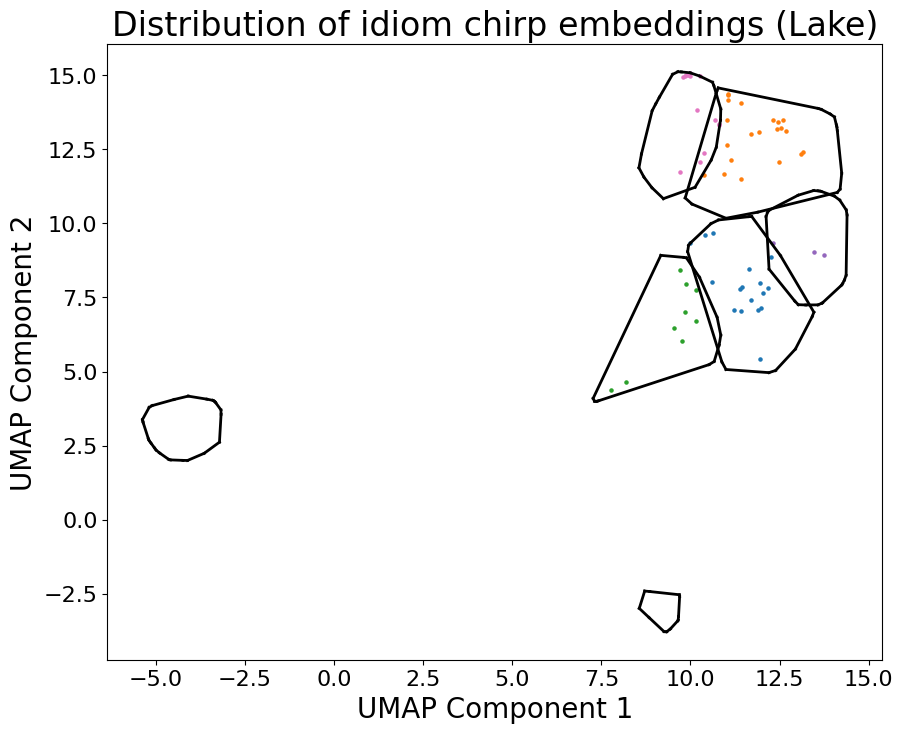

In [28]:
from scipy.spatial import ConvexHull
plt.figure(figsize=(10, 8))
idiom_chirp_attributes['cluster_idx'] = chirp_labels
exp_to_plot = 2

first_exp_attributes_embedded = idiom_chirp_attributes_embedded[:second_exp_first_row]
second_exp_attributes_embedded = idiom_chirp_attributes_embedded[second_exp_first_row:]
for i in range(NUM_CLUSTERS):
    cluster_points = idiom_chirp_attributes_embedded[idiom_chirp_attributes['cluster_idx'] == i]
    if len(cluster_points) > 2:
        hull = ConvexHull(cluster_points)
        # Plot the hull as a closed line
        for simplex in hull.simplices:
            plt.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], 'k-', lw=2, alpha=1) # 'k-' for a solid black line
    
    first_exp_cluster_points = first_exp_attributes_embedded[idiom_chirp_attributes['cluster_idx'][:second_exp_first_row] == i]
    second_exp_cluster_points = second_exp_attributes_embedded[idiom_chirp_attributes['cluster_idx'][second_exp_first_row:] == i]
    if exp_to_plot == 1:
        scatter = plt.scatter(first_exp_cluster_points[:, 0], first_exp_cluster_points[:, 1], s=5, label=f'Cluster {i}', alpha=1)
    else:
        scatter = plt.scatter(second_exp_cluster_points[:, 0], second_exp_cluster_points[:, 1], s=5, label=f'Cluster {i}', alpha=1)

plt.title(f"Distribution of idiom chirp embeddings ({exp_1_name if exp_to_plot == 1 else exp_2_name})")
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");

Evaluate various metrics about the clustering of the two sets of idiom chirps:

In [22]:
idiom_label_sequences = idiom_chirp_attributes.groupby(["file_id", "original_df"]).agg(list)["cluster_idx"].reset_index()
idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 1]

,file_id,original_df,cluster_idx
10,16693.0,1,"[2, 2, 2]"
11,16694.0,1,"[2, 1, 4, 1, 4, 1, 4]"
12,16696.0,1,"[4, 4, 4, 0, 0, 0]"
13,16697.0,1,"[6, 6, 6]"
14,16698.0,1,"[2, 0, 2, 2, 0, 4]"
...,...,...,...
460,17304.0,1,"[1, 1, 1, 4, 5, 1, 4]"
461,17308.0,1,"[1, 1, 0, 0, 6, 1, 1, 3]"
462,17309.0,1,"[6, 1, 1, 6, 4, 4]"
463,17310.0,1,"[2, 0, 0, 1, 4]"


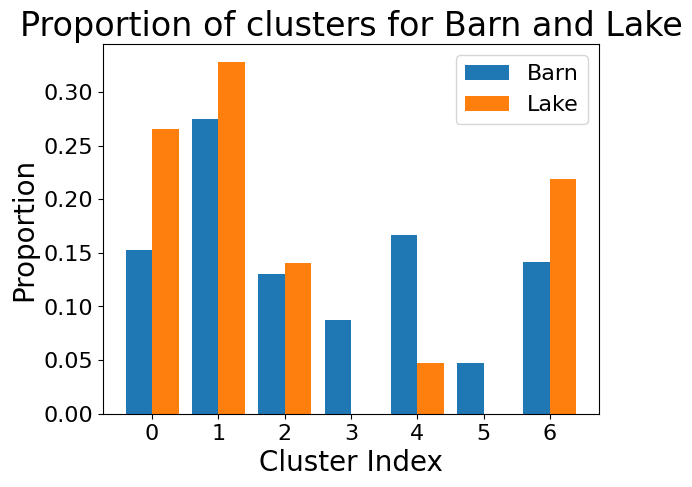

In [23]:
# FIGURE: 12.1

# plot a histogram of cluster indices across the two experiments
first_exp_clusters = idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 1]['cluster_idx'].values
second_exp_clusters = idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 2]['cluster_idx'].values
plt.hist([first_exp_clusters, second_exp_clusters], 
         bins=(np.arange(min(chirp_labels), max(chirp_labels) + 2) - 0.5), 
         density=True,
        #  stacked=True,
         )
plt.xticks(range(min(chirp_labels), max(chirp_labels) + 1))
plt.title(f"Proportion of clusters for {exp_1_name} and {exp_2_name}")
plt.xlabel("Cluster Index")
plt.ylabel("Proportion")
plt.legend([exp_1_name, exp_2_name]);

In [24]:
# FIGURE: 12.2

# find the most common cluster across both experiments
LENGTH = 1
K_MOST_COMMON = 10
SUBSEQ_TYPE = "all"
subseq_all = most_common_subsequences(idiom_label_sequences['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE, 
                         k=K_MOST_COMMON)
subseq_exp1 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 1]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE,
                         k=K_MOST_COMMON)
subseq_exp2 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 2]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE,
                         k=K_MOST_COMMON)
subseq_all = pd.DataFrame(subseq_all, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} (all)', 'Count'])
subseq_exp1 = pd.DataFrame(subseq_exp1, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} ({exp_1_name})', 'Count'])
subseq_exp2 = pd.DataFrame(subseq_exp2, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} ({exp_2_name})', 'Count'])
print(pd.concat([subseq_all, subseq_exp1, subseq_exp2], axis=1))

  Subseq (all)  Count Subseq (Barn)  Count Subseq (Lake)  Count
0         (1,)   1119          (1,)   1098          (1,)   21.0
1         (4,)    670          (4,)    667          (0,)   17.0
2         (0,)    628          (0,)    611          (6,)   14.0
3         (6,)    582          (6,)    568          (2,)    9.0
4         (2,)    529          (2,)    520          (4,)    3.0
5         (3,)    348          (3,)    348           NaN    NaN
6         (5,)    191          (5,)    191           NaN    NaN


In [25]:
# FIGURE: 12.3

# find most common transitions
LENGTH = 2
subseq_all = most_common_subsequences(idiom_label_sequences['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE, 
                         k=K_MOST_COMMON)
subseq_exp1 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 1]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE,
                         k=K_MOST_COMMON)
subseq_exp2 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 2]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE,
                         k=K_MOST_COMMON)
subseq_all = pd.DataFrame(subseq_all, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} (all)', 'Count'])
subseq_exp1 = pd.DataFrame(subseq_exp1, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} ({exp_1_name})', 'Count'])
subseq_exp2 = pd.DataFrame(subseq_exp2, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} ({exp_2_name})', 'Count'])
print(pd.concat([subseq_all, subseq_exp1, subseq_exp2], axis=1))

  Subseq (all)  Count Subseq (Barn)  Count Subseq (Lake)  Count
0       (1, 1)    411        (1, 1)    402        (1, 1)      9
1       (4, 4)    211        (4, 4)    210        (0, 1)      6
2       (6, 6)    196        (6, 6)    191        (1, 6)      5
3       (1, 4)    151        (1, 4)    151        (6, 6)      5
4       (4, 1)    137        (4, 1)    137        (2, 0)      4
5       (1, 6)    136        (6, 1)    134        (0, 0)      4
6       (6, 1)    136        (1, 6)    131        (1, 0)      4
7       (0, 0)    131        (0, 0)    127        (0, 2)      3
8       (0, 1)    120        (1, 0)    114        (6, 0)      2
9       (1, 0)    118        (0, 1)    114        (1, 2)      2


Stepping away from comparison for a second, this section allows us to describe the characteristics of a given cluster

In [26]:
ignore_columns = ["index", "OriginalIndex", "file_id", "chirp_idx", "original_df", "cluster_idx"]
cluster_profile = describe_cluster(idiom_chirp_attributes, 7, normalize=True, ignore_columns=ignore_columns)
cluster_profile

/home/ayc227/bats/src/andrew/analysis_utils.py:580: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-5.19933758 -5.19933758 -5.19933758 ...  0.61957818  5.19933758
 -5.19933758]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled_df.loc[:, columns] = scaler.transform(df.loc[:, columns])
/home/ayc227/bats/src/andrew/analysis_utils.py:580: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-5.19933758 -5.19933758 -5.19933758 ... -5.19933758 -5.19933758
 -5.19933758]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  scaled_df.loc[:, columns] = scaler.transform(df.loc[:, columns])
/home/ayc227/bats/src/andrew/analysis_utils.py:580: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-5.19933758 -5.1993375

TimeInFile        NaN
PrecedingIntrvl   NaN
HiFreq            NaN
Bndwdth           NaN
FreqMaxPwr        NaN
PrcntMaxAmpDur    NaN
FreqKnee          NaN
PrcntKneeDur      NaN
StartF            NaN
UpprKnFreq        NaN
HiFtoUpprKnAmp    NaN
HiFtoKnAmp        NaN
HiFtoFcAmp        NaN
UpprKnToKnAmp     NaN
KnToFcAmp         NaN
LdgToFcAmp        NaN
FreqCtr           NaN
FFwd32dB          NaN
FFwd20dB          NaN
FFwd15dB          NaN
FBak5dB           NaN
FFwd5dB           NaN
Bndw32dB          NaN
Amp1stQrtl        NaN
Amp2ndQrtl        NaN
Amp3rdQrtl        NaN
Amp4thQrtl        NaN
1st10kHzSlp       NaN
1st5to15kHzSlp    NaN
1st10kHzExp       NaN
1st5to15kHzExp    NaN
AmpK@start        NaN
cluster           NaN
idiom_start       NaN
idiom_end         NaN
in_idiom          NaN
dtype: float64